In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, find_peaks
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Setup: Let's use 5 subjects (Resting Data: odd numbered files) for the demo
# Ensure '1.txt', '3.txt', '5.txt', '7.txt', '9.txt' are in the same folder as this notebook.
subject_files = {1: 'ECGIDld2_db/1.txt', 2: 'ECGIDld2_db/3.txt', 3: 'ECGIDld2_db/5.txt', 4: 'ECGIDld2_db/7.txt', 5: 'ECGIDld2_db/9.txt'}
fs = 300 # Sampling frequency of the database

# Lists to hold our extracted data
X_all_fragments = []
y_labels = []

# ==============================================================================
# STAGE 1 & 2: DATA ACQUISITION & PREPROCESSING
# ==============================================================================
print("STAGE 1 & 2: Loading Data and Applying Digital Filters...")

def preprocess_signal(raw_ecg, fs=300):
    # 4th-order Butterworth Bandpass Filter (0.5 Hz - 40 Hz)
    # Removes baseline wander (breathing) and high-frequency noise (muscles)
    nyquist = 0.5 * fs
    b, a = butter(4, [0.5 / nyquist, 40.0 / nyquist], btype='bandpass')
    clean_ecg = filtfilt(b, a, raw_ecg)
    return clean_ecg

# Load just the first subject for the visual demonstration of filtering
raw_demo = np.loadtxt(subject_files[7])[:1500] # Load first 5 seconds
clean_demo = preprocess_signal(raw_demo)

# --- VISUALIZATION 1: Filtering ---
plt.figure(figsize=(12, 4))
plt.plot(raw_demo, label='Raw Noisy Signal', alpha=0.5, color='gray')
plt.plot(clean_demo, label='Filtered Signal (0.5-40Hz)', color='blue')
plt.title("Data Preprocessing: Noise & Baseline Drift Removal")
plt.xlabel("Samples"); plt.ylabel("Amplitude")
plt.legend(); plt.grid(True); plt.show()


# ==============================================================================
# STAGE 3: INITIAL FEATURE SPACE FORMATION (Segmentation)
# ==============================================================================
print("\nSTAGE 3: R-Peak Detection and P-QRS-T Window Extraction...")

def extract_pqrst(clean_ecg, subject_id, fs=300):
    # 1. R-Peak Detection (Thresholding)
    peaks, _ = find_peaks(clean_ecg, distance=int(fs*0.5), height=0.2)
    
    # 2. Window Size: 0.5 seconds = 150 samples at 300Hz 
    # (48 samples before R-peak, 102 after)
    left_win = 48
    right_win = 102
    fragments = []
    
    for peak in peaks:
        if peak - left_win >= 0 and peak + right_win < len(clean_ecg):
            fragment = clean_ecg[peak - left_win : peak + right_win]
            fragment = fragment - np.mean(fragment) # Baseline zeroing
            fragments.append(fragment)
            
    return peaks, np.array(fragments)

# Extract peaks and fragments for the demo subject
demo_peaks, demo_fragments = extract_pqrst(clean_demo, 1)

# --- VISUALIZATION 2: R-Peak Detection ---
plt.figure(figsize=(12, 3))
plt.plot(clean_demo, color='blue')
plt.plot(demo_peaks, clean_demo[demo_peaks], "rx", markersize=10, label='Detected R-Peaks')
plt.title("Segmentation: Identifying Heartbeats")
plt.legend(); plt.grid(True); plt.show()

# --- VISUALIZATION 3: Overlaid P-QRS-T Fragments (Shows Stability) ---
plt.figure(figsize=(6, 4))
for frag in demo_fragments[:10]: # Plot first 10 beats
    plt.plot(frag, color='blue', alpha=0.6)
plt.title("Extracted P-QRS-T Fragments (Overlaid)")
plt.xlabel("Samples (150 total = 0.5 sec)"); plt.ylabel("Amplitude")
plt.grid(True); plt.show()


# ==============================================================================
# BUILD THE FULL DATABASE FOR CLASSIFICATION
# ==============================================================================
# Now we loop through all 5 subjects to build our training data
for subj_id, file in subject_files.items():
    raw_data = np.loadtxt(file)
    clean_data = preprocess_signal(raw_data)
    _, fragments = extract_pqrst(clean_data, subj_id)
    
    for frag in fragments:
        X_all_fragments.append(frag)
        y_labels.append(subj_id)

X_all_fragments = np.array(X_all_fragments)
y_labels = np.array(y_labels)


# ==============================================================================
# STAGE 4: FEATURE SPACE REDUCTION (PCA)
# ==============================================================================
print("\nSTAGE 4: Dimensionality Reduction via PCA...")
print(f"Original Feature Space: {X_all_fragments.shape[7]} samples per beat.")

# Compress 150 points down to 30 Principal Components
pca = PCA(n_components=30)
X_reduced = pca.fit_transform(X_all_fragments)

print(f"Reduced Feature Space: {X_reduced.shape[7]} components per beat.")

# --- VISUALIZATION 4: PCA Scatter Plot (Shows Uniqueness) ---
# We plot the first 2 principal components to show how different people group together
plt.figure(figsize=(8, 5))
scatter = plt.scatter(X_reduced[:, 0], X_reduced[:, 1], c=y_labels, cmap='tab10', alpha=0.7)
plt.title("PCA 2D Projection: Biometric Clusters by Subject")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.colorbar(scatter, label="Subject ID")
plt.grid(True); plt.show()


# ==============================================================================
# STAGE 5: CLASSIFICATION & IDENTIFICATION
# ==============================================================================
print("\nSTAGE 5: Linear Discriminant Analysis (LDA) Classification...")

# Split data: 70% to train the lock, 30% to test it
X_train, X_test, y_train, y_test = train_test_split(X_reduced, y_labels, test_size=0.3, random_state=42)

# Train the Classifier
lda = LinearDiscriminantAnalysis()
lda.fit(X_train, y_train)

# Test the Classifier
y_pred = lda.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print("-" * 40)
print(f"BIOMETRIC IDENTIFICATION ACCURACY: {accuracy * 100:.2f}%")
print("-" * 40)

# Simulate a live authentication attempt for the presentation
print("\n[Simulation] Unknown user grabs the door handle...")
random_test_index = 15 # Pick a random heartbeat from the test set
true_identity = y_test[random_test_index]
predicted_identity = lda.predict([X_test[random_test_index]])

print(f"-> System predicts: Subject {predicted_identity}")
if predicted_identity == true_identity:
    print("-> MATCH SUCCESSFUL. Access Granted.")
else:
    print("-> MATCH FAILED. Access Denied.")

STAGE 1 & 2: Loading Data and Applying Digital Filters...


KeyError: 7

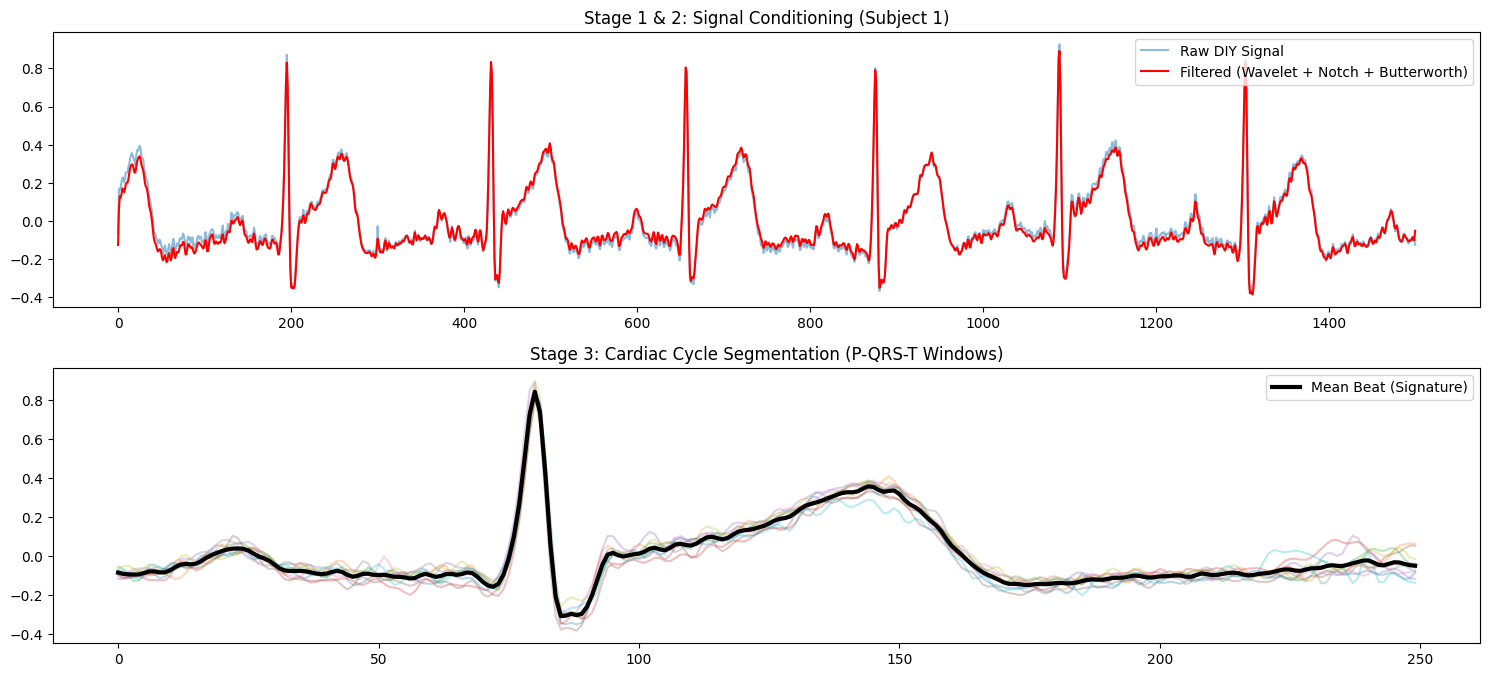

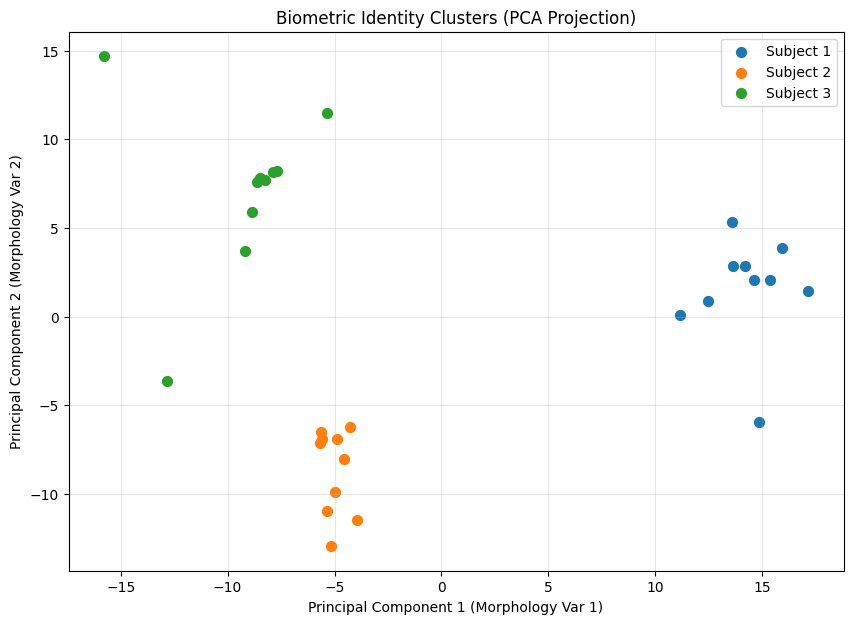

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as signal
import pywt
import os
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# --- 1. MISSING FUNCTIONS (Add these to fix the NameError) ---

def preprocess_ecg(data, fs=300):
    """
    Applies the filtering stages shown in your hardware docs: 
    Wavelet (Drift), Notch (60Hz), and Butterworth (80Hz LP).
    """
    # Baseline Drift Correction (Wavelet)
    coeffs = pywt.wavedec(data, 'db4', level=9)
    coeffs[0] = np.zeros_like(coeffs[0]) 
    data_denoised = pywt.waverec(coeffs, 'db4')

    # Mains Hum Removal (Notch Filter at 60Hz per your Step 4 doc)
    # Note: Use 50.0 for India, 60.0 for the US/Database standard
    b_notch, a_notch = signal.iirnotch(60.0, 30.0, fs)
    data_notched = signal.filtfilt(b_notch, a_notch, data_denoised)

    # High Frequency Cleanup (Butterworth Lowpass 80Hz per your Step 5 doc)
    b_low, a_low = signal.butter(4, 80/(fs/2), btype='low')
    data_final = signal.filtfilt(b_low, a_low, data_notched)
    
    return data_final[:len(data)] 

def segment_beats(signal_data, fs=300, num_beats=10):
    """
    Extracts PQRST windows (250 samples) centered on R-peaks.
    """
    # R-peak detection based on amplitude threshold
    peaks, _ = signal.find_peaks(signal_data, distance=fs*0.6, height=np.mean(signal_data)*1.2)
    
    beats = []
    for p in peaks:
        # Window: 80 samples before R, 170 after R (Total 250 samples / 0.5s)
        if p > 80 and p + 170 < len(signal_data):
            beat = signal_data[p-80 : p+170]
            beats.append(beat)
            if len(beats) == num_beats: break 
    return np.array(beats)

# --- 2. VISUALIZATION FUNCTION ---

def plot_demo(raw, clean, beats, subject_id):
    plt.figure(figsize=(15, 10))
    
    # Plot 1: Raw vs Clean (Proves your Hardware-to-Software filtering)
    plt.subplot(3, 1, 1)
    plt.plot(raw[:1500], label='Raw DIY Signal', alpha=0.5)
    plt.plot(clean[:1500], label='Filtered (Wavelet + Notch + Butterworth)', color='red')
    plt.title(f"Stage 1 & 2: Signal Conditioning (Subject {subject_id})")
    plt.legend()

    # Plot 2: Segmented Beats (Shows the unique 'Heart Fingerprint')
    plt.subplot(3, 1, 2)
    for b in beats:
        plt.plot(b, alpha=0.3)
    plt.plot(np.mean(beats, axis=0), color='black', linewidth=3, label='Mean Beat (Signature)')
    plt.title("Stage 3: Cardiac Cycle Segmentation (P-QRS-T Windows)")
    plt.legend()
    
    plt.tight_layout()
    plt.show()

# --- 3. MAIN PROCESSING LOGIC ---
fs = 300
all_beats = []
labels = []

# Demonstration using first few subjects
# Ensure your folder 'ECGIDld2_db' contains 1.txt, 3.txt, etc.
for i in [1, 3, 5]: 
    file_path = f'ECGIDld2_db/{i}.txt'
    if os.path.exists(file_path):
        raw_signal = np.loadtxt(file_path)
        
        # Now these functions exist!
        clean_signal = preprocess_ecg(raw_signal, fs)  
        beats = segment_beats(clean_signal, fs)
        
        if i == 1: 
            plot_demo(raw_signal, clean_signal, beats, (i+1)//2)
        
        all_beats.extend(beats)
        labels.extend([(i+1)//2] * len(beats))

# --- 4. PCA CLUSTERING PLOT ---
if len(all_beats) > 0:
    # Scale data before PCA for better clustering
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(all_beats)
    
    pca = PCA(n_components=2) 
    X_pca = pca.fit_transform(X_scaled)

    plt.figure(figsize=(10, 7))
    for s_id in np.unique(labels):
        mask = (np.array(labels) == s_id)
        plt.scatter(X_pca[mask, 0], X_pca[mask, 1], label=f'Subject {s_id}', s=50)
    plt.title("Biometric Identity Clusters (PCA Projection)")
    plt.xlabel("Principal Component 1 (Morphology Var 1)")
    plt.ylabel("Principal Component 2 (Morphology Var 2)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
else:
    print("No data found. Please check your file paths.")